# 批量生成 `sag.png` 与 `cor.png`

这个 notebook 会遍历 `logs` 下实验目录，对每个包含 `image_pred.npy`（可选 `image_gt.npy`）的目录生成 `sag.png` 和 `cor.png`。

关键规则：先用 `Path.exists()` 判断 `sag.png` 与 `cor.png` 是否都存在；若都存在，直接跳过并**不读取** `.npy`。

In [ ]:
from pathlib import Path
import subprocess

LOGS_DIR = Path('./logs')
assert LOGS_DIR.exists(), f'logs not found: {LOGS_DIR}'

cmd = [
    'python',
    'generate_sag_cor_slices.py',
    '--logs-dir', str(LOGS_DIR),
    '--verbose',
]
print(' '.join(cmd))
subprocess.run(cmd, check=False)

## 1) 导入依赖与路径配置

- 导入 `Path`、`numpy`、`matplotlib`
- 定义 `logs` 根目录与命名约定
- 设置默认切片策略（中间切片）

In [8]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 根目录：可按需修改
LOGS_DIR = Path("./logs")
RECURSIVE = True

# 是否强制重处理：True 时不跳过已有 png
FORCE_REPROCESS = True

# 文件命名约定
PRED_NAME = "image_pred.npy"
GT_NAME = "image_gt.npy"
SAG_PNG = "sag.png"
COR_PNG = "cor.png"

# 切片索引策略：None 表示自动取中间层
SAG_INDEX = None  # 沿 W 轴
COR_INDEX = None  # 沿 H 轴

# HU 与窗宽窗位设置
HU_SCALE = 2500.0  # npy * HU_SCALE -> HU
WINDOW_LEVEL = 800.0
WINDOW_WIDTH = 1600.0
WINDOW_VMIN = WINDOW_LEVEL - WINDOW_WIDTH / 2
WINDOW_VMAX = WINDOW_LEVEL + WINDOW_WIDTH / 2

print(f"LOGS_DIR = {LOGS_DIR.resolve()}")
print(f"FORCE_REPROCESS = {FORCE_REPROCESS}")
print(f"Window: WL={WINDOW_LEVEL}, WW={WINDOW_WIDTH}, vmin={WINDOW_VMIN}, vmax={WINDOW_VMAX}")

LOGS_DIR = /home/jym/naf_cbct/logs
FORCE_REPROCESS = True
Window: WL=800.0, WW=1600.0, vmin=0.0, vmax=1600.0


## 2) 扫描 `logs` 下所有实验与 `eval/epoch_*` 子目录

优先定位包含 `image_pred.npy` 或 `image_gt.npy` 的目录，并打印总数。

In [2]:
if RECURSIVE:
    pred_files = list(LOGS_DIR.rglob(PRED_NAME))
    gt_files = list(LOGS_DIR.rglob(GT_NAME))
else:
    pred_files = list(LOGS_DIR.glob(f"**/{PRED_NAME}"))
    gt_files = list(LOGS_DIR.glob(f"**/{GT_NAME}"))

candidate_dirs = {p.parent for p in pred_files}
candidate_dirs.update({g.parent for g in gt_files})
candidate_dirs = sorted(candidate_dirs)

print(f"Found pred files: {len(pred_files)}")
print(f"Found gt files:   {len(gt_files)}")
print(f"Candidate dirs:   {len(candidate_dirs)}")

for d in candidate_dirs[:10]:
    print(" -", d)
if len(candidate_dirs) > 10:
    print(" ...")

Found pred files: 17
Found gt files:   17
Candidate dirs:   17
 - logs/20260313_CT_2views_sag_centerPad_noLrSchedule_fixVESDEsag_annealing_sds0.05_startFrom0_interval10/volume-covid19-A-0377_ct/eval
 - logs/20260313_CT_2views_sag_centerPad_noLrSchedule_fixVESDEsag_noannealing_sds0.01_startFrom0_interval10/volume-covid19-A-0377_ct/eval
 - logs/20260313_CT_2views_sag_centerPad_noLrSchedule_fixVESDEsag_noannealing_sds0.02_startFrom0_interval10/volume-covid19-A-0377_ct/eval
 - logs/20260313_CT_2views_sag_centerPad_noLrSchedule_fixVESDEsag_noannealing_sds0.05_startFrom0_interval10/volume-covid19-A-0377_ct/eval
 - logs/ct_2views_sds0.01_startFrom0_interval10/volume-covid19-A-0377_ct/eval
 - logs/ct_2views_sds0.01_startFrom0_interval10_noLrSchedule/volume-covid19-A-0377_ct/eval
 - logs/ct_2views_sds0.05_startFrom0_interval10_noLrSchedule/volume-covid19-A-0377_ct/eval
 - logs/ct_2views_sds0.05_startFrom0_interval20_noLrSchedule/volume-covid19-A-0377_ct/eval
 - logs/ct_2views_sds0.05_startFrom0

## 3) 定义体数据切片与可视化保存函数（sag/cor）

- 输入 3D 体数据（默认形状 `[H, W, D]`）
- 自动选中间切片
- 支持 Pred/GT 并排可视化并保存 PNG

In [3]:
def ensure_3d(arr: np.ndarray, path: Path) -> np.ndarray:
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape={arr.shape} at {path}")
    return arr


def get_sag_slice(vol: np.ndarray, index=None) -> np.ndarray:
    # vol: [H, W, D], sag -> 固定 W 轴
    h, w, d = vol.shape
    idx = w // 2 if index is None else int(index)
    idx = max(0, min(w - 1, idx))
    return vol[:, idx, :]


def get_cor_slice(vol: np.ndarray, index=None) -> np.ndarray:
    # vol: [H, W, D], cor -> 固定 H 轴
    h, w, d = vol.shape
    idx = h // 2 if index is None else int(index)
    idx = max(0, min(h - 1, idx))
    return vol[idx, :, :]


def save_plane_png(
    pred_plane: np.ndarray,
    out_path: Path,
    gt_plane: np.ndarray = None,
    title: str = "",
    vmin: float = None,
    vmax: float = None,
):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if gt_plane is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=140)
        ax.set_title(f"{title} | Pred")
        ax.imshow(pred_plane, cmap="gray", vmin=vmin, vmax=vmax)
        ax.axis("off")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=140)
        axes[0].set_title(f"{title} | GT")
        axes[0].imshow(gt_plane, cmap="gray", vmin=vmin, vmax=vmax)
        axes[0].axis("off")
        axes[1].set_title(f"{title} | Pred")
        axes[1].imshow(pred_plane, cmap="gray", vmin=vmin, vmax=vmax)
        axes[1].axis("off")
    plt.tight_layout()
    fig.savefig(out_path)
    plt.close(fig)

## 4) 实现单个 `epoch` 目录处理逻辑（先 `Path.exists()` 再决定是否读取 `.npy`）

先判断 `sag.png` 和 `cor.png` 是否都存在：
- 都存在：跳过，不读 `.npy`
- 任意缺失：再读取 `.npy` 并生成缺失图片

In [9]:
def process_one_dir(eval_dir: Path, sag_index=None, cor_index=None):
    pred_path = eval_dir / PRED_NAME
    gt_path = eval_dir / GT_NAME
    sag_png = eval_dir / SAG_PNG
    cor_png = eval_dir / COR_PNG

    # 默认行为：若两张图都存在则跳过；强制模式下不跳过
    if (not FORCE_REPROCESS) and sag_png.exists() and cor_png.exists():
        return "skipped", f"exists: {eval_dir}"

    if not pred_path.exists():
        return "missing", f"missing pred: {pred_path}"

    try:
        pred = ensure_3d(np.load(pred_path), pred_path) * HU_SCALE
        gt = None
        if gt_path.exists():
            gt = ensure_3d(np.load(gt_path), gt_path) * HU_SCALE

        if FORCE_REPROCESS or (not sag_png.exists()):
            pred_sag = get_sag_slice(pred, sag_index)
            gt_sag = get_sag_slice(gt, sag_index) if gt is not None else None
            save_plane_png(
                pred_sag,
                sag_png,
                gt_sag,
                title="Sagittal",
                vmin=WINDOW_VMIN,
                vmax=WINDOW_VMAX,
            )

        if FORCE_REPROCESS or (not cor_png.exists()):
            pred_cor = get_cor_slice(pred, cor_index)
            gt_cor = get_cor_slice(gt, cor_index) if gt is not None else None
            save_plane_png(
                pred_cor,
                cor_png,
                gt_cor,
                title="Coronal",
                vmin=WINDOW_VMIN,
                vmax=WINDOW_VMAX,
            )

        return "processed", f"done: {eval_dir}"
    except Exception as exc:
        return "error", f"{eval_dir} | {exc}"

## 5) 批量处理所有实验并输出处理统计

记录 `processed / skipped / missing / error` 统计，并打印错误样本路径。

In [10]:
stats = {"processed": 0, "skipped": 0, "missing": 0, "error": 0}
errors = []

for eval_dir in candidate_dirs:
    status, msg = process_one_dir(eval_dir, sag_index=SAG_INDEX, cor_index=COR_INDEX)
    stats[status] += 1
    if status == "error":
        errors.append(msg)

print("\n=== Summary ===")
for k, v in stats.items():
    print(f"{k:>9}: {v}")

if errors:
    print("\n=== Errors (first 20) ===")
    for e in errors[:20]:
        print(" -", e)


=== Summary ===
processed: 17
  skipped: 0
  missing: 0
    error: 0


## 6) 可选检查单个样例切片显示（`matplotlib`）

复用你提供的示例路径格式，验证轴方向与显示是否符合预期。

example_dir: logs/20260313_CT_2views_sag_centerPad_noLrSchedule_fixVESDEsag_annealing_sds0.05_startFrom0_interval10/volume-covid19-A-0377_ct/eval
pred shape: (256, 256, 128)
gt shape: (256, 256, 128)
Display window: WL=800.0, WW=1600.0


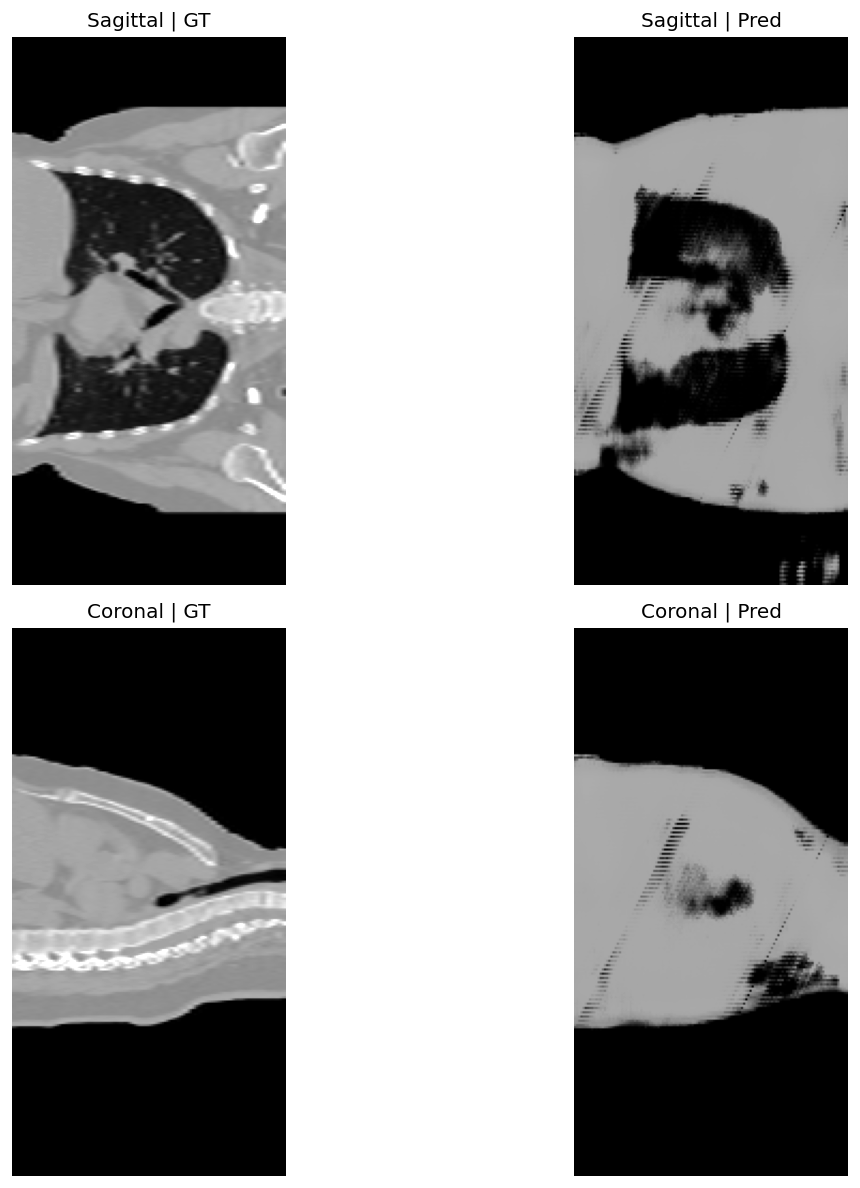

In [6]:
# 按你的示例路径风格，优先找一个可用目录
example_dir = next((d for d in candidate_dirs if (d / PRED_NAME).exists()), None)

if example_dir is None:
    print("No example dir found.")
else:
    pred = np.load(example_dir / PRED_NAME) * HU_SCALE
    gt = np.load(example_dir / GT_NAME) * HU_SCALE if (example_dir / GT_NAME).exists() else None
    pred = ensure_3d(pred, example_dir / PRED_NAME)
    if gt is not None:
        gt = ensure_3d(gt, example_dir / GT_NAME)

    print("example_dir:", example_dir)
    print("pred shape:", pred.shape)
    if gt is not None:
        print("gt shape:", gt.shape)
    print(f"Display window: WL={WINDOW_LEVEL}, WW={WINDOW_WIDTH}")

    fig, axes = plt.subplots(2, 2 if gt is not None else 1, figsize=(12, 10), dpi=120)

    pred_sag = get_sag_slice(pred, SAG_INDEX)
    pred_cor = get_cor_slice(pred, COR_INDEX)

    if gt is not None:
        gt_sag = get_sag_slice(gt, SAG_INDEX)
        gt_cor = get_cor_slice(gt, COR_INDEX)

        axes[0, 0].set_title("Sagittal | GT")
        axes[0, 0].imshow(gt_sag, cmap="gray", vmin=WINDOW_VMIN, vmax=WINDOW_VMAX)
        axes[0, 0].axis("off")

        axes[0, 1].set_title("Sagittal | Pred")
        axes[0, 1].imshow(pred_sag, cmap="gray", vmin=WINDOW_VMIN, vmax=WINDOW_VMAX)
        axes[0, 1].axis("off")

        axes[1, 0].set_title("Coronal | GT")
        axes[1, 0].imshow(gt_cor, cmap="gray", vmin=WINDOW_VMIN, vmax=WINDOW_VMAX)
        axes[1, 0].axis("off")

        axes[1, 1].set_title("Coronal | Pred")
        axes[1, 1].imshow(pred_cor, cmap="gray", vmin=WINDOW_VMIN, vmax=WINDOW_VMAX)
        axes[1, 1].axis("off")
    else:
        axes = np.array(axes).reshape(2, 1)
        axes[0, 0].set_title("Sagittal | Pred")
        axes[0, 0].imshow(pred_sag, cmap="gray", vmin=WINDOW_VMIN, vmax=WINDOW_VMAX)
        axes[0, 0].axis("off")

        axes[1, 0].set_title("Coronal | Pred")
        axes[1, 0].imshow(pred_cor, cmap="gray", vmin=WINDOW_VMIN, vmax=WINDOW_VMAX)
        axes[1, 0].axis("off")

    plt.tight_layout()
    plt.show()

In [7]:
# 临时检查：当前示例 pred/gt 的 HU 范围
print('HU_SCALE =', HU_SCALE)
print('pred HU range:', float(np.min(pred)), float(np.max(pred)))
if gt is not None:
    print('gt   HU range:', float(np.min(gt)), float(np.max(gt)))
print('window HU range:', float(WINDOW_VMIN), float(WINDOW_VMAX))

HU_SCALE = 2500.0
pred HU range: 5.412113904860532e-22 1085.2376708984375
gt   HU range: 0.0 2564.30615234375
window HU range: 0.0 1600.0
